In [26]:
from langchain_openai import ChatOpenAI

In [27]:
import numpy as np
import pandas as pd
import os
import sys

from dotenv import load_dotenv
from pydantic import BaseModel

from langchain_core.messages import HumanMessage
import chardet

load_dotenv()

True

In [28]:
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.max_columns', None)

# Agent

In [29]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage

import numpy as np
import pandas as pd
import os
import sys
from pydantic import BaseModel
import chardet
from typing import Any
import json
import importlib

from dotenv import load_dotenv

load_dotenv()

True

In [30]:
class GraphState(MessagesState):
    raw_data: dict
    file_path: str
    parse_code_file_path: str
    scanner_schema_info: dict
    function: str
    df: Any
    retry_count: int
    error_message: str


In [31]:
def load_json(state: GraphState):
    with open(state["file_path"], 'rb') as f:
        raw_data = f.read()
        result = chardet.detect(raw_data)
        encoding = result['encoding']
    
    data = json.loads(raw_data.decode(encoding))
    return {"raw_data": data}

In [32]:
def extract_internal_structure(data, path="", depth=0, max_depth=5):
    """
    Recursively discovers the schema of a JSON object.
    Identifies arrays, object keys, and provides sample leaf-node values.
    """
    if depth > max_depth:
        return "..."

    if isinstance(data, dict):
        structure = {}
        for key, value in data.items():
            structure[key] = extract_internal_structure(value, f"{path}.{key}", depth + 1)
        return structure

    elif isinstance(data, list):
        if len(data) == 0:
            return []
        # Analyze the first element as a template for the list structure
        list_sample = extract_internal_structure(data[0], f"{path}[0]", depth + 1)
        return [f"Array(size={len(data)})", list_sample]

    else:
        # Return the type and a small sample of the value
        return f"{type(data).__name__} (e.g., {str(data)[:30]})"

def process_scanner_output(state: GraphState):
    # Generate the structural map
    structure_map = extract_internal_structure(state["raw_data"])
    
    # Identify the 'Entry Points' (Keys that likely hold the vulnerability list)
    # We look for large arrays at the top levels
    entry_points = []
    if isinstance(state["raw_data"], dict):
        for k, v in state["raw_data"].items():
            if isinstance(v, list) and len(v) > 0:
                entry_points.append(k)

    scanner_schema_info =  {
        "detected_entry_points": entry_points,
        "schema_map": structure_map
    }

    return {"scanner_schema_info": scanner_schema_info}

In [33]:
class ParseFunction(BaseModel):
    function_name: str
    function: str

In [34]:
llm = ChatOpenAI(model = "gpt-4.1-mini").with_structured_output(ParseFunction)

In [35]:
def generate_parse_code(state: GraphState):
    error_context = ""
    if state.get("error_message"):
        error_context = f"""
### PREVIOUS ERROR ENCOUNTERED:
The last version of the function failed with the following error/issue:
{state["error_message"]}

Here is the last version of the function:
{state["function"]}

Please analyze the metadata again and fix the logic to ensure data is correctly extracted.
"""
        
    message = f"""
You are an expert AIOps Developer and Data Engineer specializing in automated security telemetry normalization.

### CONTEXT:
I am building a "Zero-Touch" vulnerability remediation pipeline. I have already analyzed a security scanner's output and extracted its structural metadata.

### INPUT METADATA:
{state["scanner_schema_info"]}

### TASK:
Write a Python function `flatten_vulnerabilities_to_df(scan_output)` that flattens the vulnerability data into a pandas DataFrame.

### CONSTRAINTS & LOGIC:
1. DATA LOCATION: Do not look for 'detected_entry_points' inside the 'scan_output'. Instead, use the value(s) provided in the METADATA above to know which keys in 'scan_output' contain the vulnerability data.
2. BRANCHING LOGIC:
   - If the metadata indicates vulnerabilities are nested within a list of groups (e.g., Trivy 'Results' -> 'Vulnerabilities'), you MUST loop through the groups and concatenate the flattened results.
   - If the metadata indicates a direct list (e.g., Snyk 'vulnerabilities' or Grype 'matches'), you MUST pass the entire list to pd.json_normalize() in one vectorized call.
3. ZERO-TOUCH EXTRACTION: Use pd.json_normalize(sep='.') to ensure every nested field (e.g., CVSS scores, identifiers) becomes a separate column. Do not manually select or hardcode column names.
4. DEFENSIVE CODING: Return an empty DataFrame if the target keys are missing or the lists are empty.

### OUTPUT:
Provide only the Python function. No conversational filler.

{error_context}
"""
    
    result = llm.invoke(
    [
        HumanMessage(
            content = message
        )
    ]
)
    
    return {"function": result.function, "retry_count": state["retry_count"] + 1}

In [36]:
def save_parse_code(state: GraphState):
    with open(state["parse_code_file_path"], "w") as f:
        f.write(state["function"])
    return {}

In [37]:
def execute_parse_code(state: GraphState):
    try:
        # Import and execute logic (from your execute_parse_code)
        spec = importlib.util.spec_from_file_location("dynamic_mod", state["parse_code_file_path"])
        module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(module)
        
        df = module.flatten_vulnerabilities_to_df(state["raw_data"])
        
        # Validation Check: Is the DF empty?
        if df is None or df.empty:
            return {
                "error_message": "Execution successful, but the resulting DataFrame is EMPTY. Ensure you are targeting the correct nested keys.",
                "df": df
            }
        
        return {"df": df, "error_message": "SUCCESS"}

    except Exception as e:
        return {
            "error_message": f"Runtime Error: {str(e)}",
            "df": None
        }

In [38]:
def should_retry(state: GraphState):
    # Stop if successful
    if state.get("error_message") == "SUCCESS":
        return "Success/Retry Limit Exceeded"
    
    # Stop if we've tried too many times (e.g., 5 retries)
    if state.get("retry_count", 0) >= 3:
        print("Max retries reached. Manual intervention required.")
        return "Success/Retry Limit Exceeded"
    
    # Otherwise, loop back to generation
    print(f"Validation failed: {state['error_message']}. Retrying...")
    return "Validation Failed"

In [39]:
graph = StateGraph(GraphState)

graph.add_node("load_scanner_output", load_json)
graph.add_node("get_schema_structure", process_scanner_output)
graph.add_node("generate_parse_code", generate_parse_code)
graph.add_node("save_parse_code", save_parse_code)
graph.add_node("execute_parse_code_and_validate_execution", execute_parse_code)

graph.add_edge(START, "load_scanner_output")
graph.add_edge("load_scanner_output", "get_schema_structure")
graph.add_edge("get_schema_structure", "generate_parse_code")
graph.add_edge("generate_parse_code", "save_parse_code")
graph.add_edge("save_parse_code", "execute_parse_code_and_validate_execution")
graph.add_conditional_edges("execute_parse_code_and_validate_execution", should_retry, {"Success/Retry Limit Exceeded": END, "Validation Failed": "generate_parse_code"})

workflow = graph.compile()

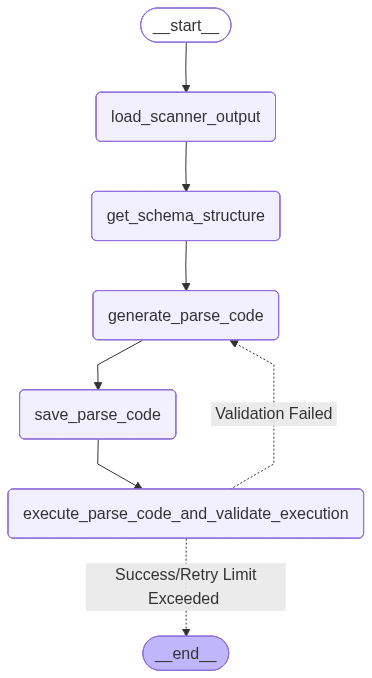

In [40]:
workflow

In [41]:
result = workflow.invoke({"file_path": r"Raw Scanner Outputs\new_trivy_scan.json", "parse_code_file_path": "generated_parser_func.py", "retry_count": 0})

In [42]:
df = result["df"]

In [43]:
df.shape

(1265, 54)

In [44]:
pd.set_option('display.max_colwidth', None)

In [50]:
df[df['FixedVersion'].notnull()].iloc[50]

VulnerabilityID                                                                                                                                                                                                                                                                                                                                                                                                         CVE-2026-42009
PkgID                                                                                                                                                                                                                                                                                                                                                                                                   libgnutls30t64@3.8.12-2ubuntu1
PkgName                                                                                                                                                   

In [46]:
df.shape

(1265, 54)